# Hierarchical Clustering - UPGMA

---
## Learning Objectives

1. Implement a distance-based phylogeny neighbor joining algorithm
1. Understanding of hierarchical clustering
1. Manipulation of arrays and lists in Python


---
## Imports
You will need to install a two new packages to properly render your phylogenetic trees. Using your preferred package manager, install both [`biopython`](https://biopython.org/) and `matplotlib` into your virtual environments.

For example:
```bash
$ micromamba create -n module06 -c bioconda -c conda-forge python numpy matplotlib biopython
```

In [56]:
from typing import List, Tuple, Dict
from io import StringIO

import matplotlib.pyplot as plt
from Bio import Phylo
import numpy as np

---
## Background

Today we will implement a distance-based phylogenetic tree construction method using the Neighbor-Joining (NJ) algorithm and Smith-Waterman local alignment scores. Unlike UPGMA (Unweighted Pair Group Method using Arithmetic averages), NJ produces unrooted trees and does not assume a constant evolutionary rate across lineages, making it more biologically realistic for analyzing sequence relationships.

We will use HIV-1 reverse transcriptase sequences to construct our phylogenetic tree. The Smith-Waterman algorithm will be used to generate pairwise local alignment scores, which will then be converted into distances for tree construction. This approach is particularly suitable for HIV sequence analysis as it:
1. Handles sequence variations effectively through local alignment
2. Accounts for potential rate heterogeneity across different viral strains
3. Does not assume a molecular clock

The ultimate output will be an unrooted phylogenetic tree representing the evolutionary relationships between the HIV-1 sequences, visualized using the ete3 library. This method provides insights into viral diversity and evolutionary patterns while avoiding the assumptions of simpler hierarchical clustering approaches.

The key innovations of this implementation are:
- Use of Smith-Waterman for sensitive local alignment scoring
- Implementation of Neighbor-Joining for unrooted tree construction
- More biologically realistic evolutionary model

## Neighbor-Joining Algorithm

**Input**: Distance matrix $D$ for $n$ sequences

**Initialization**:
- Let $n$ be the number of sequences
- Assign each sequence $i$ to its own leaf node
- Initialize tree $T$ with leaf nodes

**Iteration**:
While $n > 2$:
1. Calculate Q-matrix where:
   $Q(i,j) = (n-2)d(i,j) - \sum_{k=1}^n d(i,k) - \sum_{k=1}^n d(j,k)$

2. Find pair $(i,j)$ with minimum $Q(i,j)$

3. Calculate branch lengths:
   $d_i = \frac{d(i,j) + (r_i - r_j)/(n-2)}{2}$
   $d_j = d(i,j) - d_i$
   where $r_i = \sum_{k=1}^n d(i,k)$

4. Create new node $k$
   - Add branches from $k$ to $i$ and $j$ with lengths $d_i$ and $d_j$

5. Update distances to remaining nodes $x$:
   $d(k,x) = \frac{d(i,x) + d(j,x) - d(i,j)}{2}$

6. Remove nodes $i$ and $j$
7. Add node $k$ to active nodes
8. $n = n - 1$

**Termination**:
When $n = 2$ with remaining nodes $i$ and $j$:
- Add final branch between $i$ and $j$ with length $d(i,j)$
- Return unrooted tree $T$

---
## Distance metrics for comparing sequences

### Smith-Waterman
This was previously implemented. Feel free to import if you know how...or Copy & Paste.



In [57]:
def read_fasta(filename: str) -> Dict[str, str]:
    """Reads sequences from FASTA file.

    Args:
        filename (str): Path to FASTA file containing HIV RT sequences

    Returns:
        Dict[str, str]: Dictionary mapping sequence IDs to sequences

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> len(seqs) > 0
        True
    """
    # initialize
    seqs = {}
    curr_name = ""
    curr_seq = ""

    # open the file
    with open(filename, mode="r", encoding="utf-8") as infile:
        # iterate over lines
        for line in infile:
            # check if line is header
            if ">" in line:

                # this will run on the first line, but also any time we start a new sequence
                # so if this isn't the first line in the file, we'll have a sequence to pack into the dict here
                if curr_name and curr_seq:
                    # this tells us the last sequence we were looking at is now done, so we can pack it up
                    seqs[curr_name] = curr_seq

                    # now clear the current sequence
                    curr_seq = ""

                # and update the title for the next sequence we're about to look at (the names are at the end of the headers)
                curr_name = line.strip().split()[-1]

            else:
                # here, the current line isn't a header, so it's just a part of a sequence
                # add the current line to the current sequence we're building
                curr_seq += line.strip()

    
    # pack up the last sequence
    seqs[curr_name] = curr_seq
    
    # report the dict of sequences
    return seqs


In [58]:
from textdistance import smith_waterman

"""
From our insightful meeting with Marcus, we learned about the textdistance package. 

Textdistance has ~30 in-built algorithms for calculating sequence similarity and distance, including one for Smith Waterman
The documentation for this package is a little lacking, but some toying around in the python console revealed that
the Smith-Waterman distance it calculates for two sequences is essentially just the similarity score for the two sequences subtracted 
from the sequence length. The normalized versions of the similarity and distance scores are then generated by dividing
the similarity or distance by the length of the aligned sequences. 

The module makes an object representing a template for a Smith-Waterman alignment matrix where you parameterize stuff like mismatch 
# and gap penalties to calc the scores. Then the matrix gets filled out according to that scoring scheme when you pass it sequences. 
"""

'\nFrom our insightful meeting with Marcus, we learned about the textdistance package. \n\nTextdistance has ~30 in-built algorithms for calculating sequence similarity and distance, including one for Smith Waterman\nThe documentation for this package is a little lacking, but some toying around in the python console revealed that\nthe Smith-Waterman distance it calculates for two sequences is essentially just the similarity score for the two sequences subtracted \nfrom the sequence length. The normalized versions of the similarity and distance scores are then generated by dividing\nthe similarity or distance by the length of the aligned sequences. \n\nThe module makes an object representing a template for a Smith-Waterman alignment matrix where you parameterize stuff like mismatch \n# and gap penalties to calc the scores. Then the matrix gets filled out according to that scoring scheme when you pass it sequences. \n'

In [59]:
def build_distance_matrix(sequences: Dict[str, str]) -> Tuple[np.ndarray, List[str]]:
    """Builds DISTANCE (not similiarity) matrix using Smith-Waterman scores.

    Args:
        sequences (Dict[str, str]): Dictionary of HIV RT sequences

    Returns:
        Tuple[np.ndarray, List[str]]: Distance matrix and list of sequence IDs

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> mat[0:3, 0:3]  # Show 3x3 slice of distance matrix
        array([[0.000, 0.004, 0.012],
              [0.004, 0.000, 0.012],
              [0.012, 0.012, 0.000]])
        >>> len(ids)  # Number of sequences
        19
    """
    # initialize an N x N matrix, where N is number of sequences
    # use the same dtype as the output from the textdistance.smith_waterman function
    dist_matrix = np.zeros(shape=(len(sequences), len(sequences)), dtype=np.float64)

    # initialize variables tracking the current row and column we're on in the distance matrix
    seq_ids = []
    # iterate over indices and the sequence IDs of the sequences dict
    for nrow, row_id in enumerate(sequences.keys()):
        for ncol, col_id in enumerate(sequences.keys()):
            
            # check if we've already hit this combination (scores are symmetrical and initialize at 0)
            # we hit position (nrow, ncol) before we hit position (ncol, nrow)
            # also check if we're comparing a sequence to itself- since the distance is always 0, we can skip that calculation
            if dist_matrix[nrow][ncol] == 0 and nrow != ncol:

                # get the distance score for the current combination of sequences (between 0 and 1)
                curr_dist = smith_waterman.normalized_distance(sequences[row_id], sequences[col_id])

                # put the current score into the associated positions on the graph
                # the dist between 2 sequences will be the same regardless of which one you start measuring from
                dist_matrix[nrow][ncol] = curr_dist
                dist_matrix[ncol][nrow] = curr_dist

        # add the current species name to the list of seqIDs
        seq_ids.append(row_id)
    
    # report the distance matrix
    return dist_matrix, seq_ids


In [80]:
def build_q_matrix(dist_matrix: np.ndarray) -> np.ndarray:
    """
    Function to create a Q matrix to identify the most related pair for clustering

    Parameters
    ----------
    dist_matrix: np.ndarray
        an N x N 2darray of distances, where N is the number of species
    
    Returns
    -------
    np.ndarray
        an N x N 2darray of transformed distances
    """
    # initialize a matrix of the right shape, using np.inf as the default value so argmin doesn't identify diagonals
    q_matrix = np.full(shape=dist_matrix.shape, fill_value=np.inf)
    nrow = q_matrix.shape[0]
    ncol = q_matrix.shape[1]

    # raise an error if the matrix isn't square
    if nrow != ncol:
        raise IndexError("Expected a matrix of shape N by N, and got matrix of shape {dist_matrix.shape}")

    # iterate through the rows and columns
    for i in range(0, nrow):
        # iterate over every column with a number greater than i (avoids comparisons to self and redundant comparisons)
        for j in range(i+1, ncol):
            # apply q equation for i and j
            q_ij = (nrow - 2) * dist_matrix[i,j] - sum(dist_matrix[i,:]) - sum(dist_matrix[j,:])
            # now write this value to the q matrix
            q_matrix[i,j] = q_ij
            q_matrix[j,i] = q_ij
    
    return q_matrix


In [99]:
from tree_object_utils import Node, Tree


def get_limb_lengths(dist_matrix: np.ndarray, i: int, j: int) -> tuple[int, int]:
    """
    Function that calculates the limb lengths for species i and j on the distance matrix

    NOTE: this might break if i and j aren't as close to each other as possible on the tree, so make sure
          only to run this on species that have been selected using the Q matrix

    Parameters
    ----------
    dist_matrix : np.ndarray
        additive distance matrix for each pair of species
    i : int
        a row/column number for one of the species being looked at
    j : int
        the row/column number for the other of the species being looked at

    Returns
    -------
    tuple[int, int]
        the limb length for species i, followed by the limb length for species j
    """
    # get the sums across the rows 
    sumrow_i = np.sum(dist_matrix[i,])
    sumrow_j = np.sum(dist_matrix[j,])

    num_species = dist_matrix.shape[0]

    limb_length_i = ( dist_matrix[i,j] + ( (sumrow_i - sumrow_j) / (num_species - 2) ) ) / 2
    limb_length_j = dist_matrix[i,j] - limb_length_i
    
    return (limb_length_i, limb_length_j)


def get_internal_dist(dist_matrix: np.ndarray, i: int, j: int) -> list[float]:
    """
    Function that calculates the distances from the shared parent of species i and species j
    to all other species on the distance matrix

    Parameters
    ----------
    dist_matrix : np.ndarray
        additive matrix of evolutionary distances between species
    i : int
        row/column number for one of the child species
    j : int
        row/column number for the other of the child species

    Returns
    -------
    np.ndarray
        an array of all the distances between this internal node to all other nodes on the matrix 
        that DON'T descend from this one
        NOTE: the indices in this array will line up with what the seq_labels and dist_matrix look like 
        AFTER removing i and j from them
    """
    # initialize the list of distances
    distances = []

    # iterate through all specis that don't descend from the parent of i and j (iterating through the row/col numbers)
    for species_idx in range(dist_matrix.shape[0]):
        
        # skip species i and j
        if species_idx == i or species_idx == j:
            continue

        # apply the distance formula
        curr_dist = ( dist_matrix[species_idx, i] + dist_matrix[species_idx, j] - dist_matrix[i, j] ) / 2
        distances.append(curr_dist)

    return distances

In [ ]:
def neighbor_joining(
    distance_matrix: np.ndarray,
    labels: List[str]
) -> Tree:
    """Implements Neighbor-Joining algorithm for phylogenetic tree construction.

    Args:
        distance_matrix (np.ndarray): Distance matrix from Smith-Waterman scores
        labels (List[str]): Sequence identifiers

    Returns:
        str: Newick format tree string

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> tree = neighbor_joining(mat, ids)
        >>> tree.startswith("((DM1:0.002,DM2:0.002)")  # Start of Newick string
        True
        >>> tree.count(",")  # Number of separators in tree
        18
    """

    # copying the distance matrix
    working_distances = distance_matrix.copy().astype(float)
    working_labels = labels.copy()
    num_species = len(working_labels)

    # initialize an empty tree object to build into
    graph = Tree()
    print(f"Empty graph:\n{graph.top_layer}")

    while num_species > 2:

        # build Q matrix and find the pair (i, j) with minimum Q value
        Q = build_q_matrix(working_distances)
        # convert the minimum Q value to row and column co-ordinates
        i, j = np.unravel_index(np.argmin(Q), Q.shape)

        # calculate branch lengths for i and j to their new internal node
        limb_i, limb_j = get_limb_lengths(working_distances, int(i), int(j))

        # collect the indices of all sequences that are NOT i or j
        remaining = [k for k in range(num_species) if k != i and k != j]

        # calculate distances from the new internal node to every remaining sequence
        internal_dists = get_internal_dist(working_distances, int(i), int(j))

        # make node objects for i and j if they don't exist, otherwise access them by name
        if working_labels[i] in graph.nodes:
            node_i = graph.nodes[working_labels[i]]
        else:
            node_i = Node(working_labels[i], limb_i)
            graph.add_node(node_i)
        
        if working_labels[j] in graph.nodes:
            print(graph.nodes)
            node_j = graph.nodes[working_labels[j]]
        else:
            node_j = Node(working_labels[j], limb_j)
            graph.add_node(node_j)

        # create a node parental to i and j
        parent_name = graph.create_parent([node_i, node_j], min(internal_dists))

        # build reduced matrix
        size = len(remaining)
        new_dists = np.zeros((size + 1, size + 1))

        # copy distances among remaining nodes
        # prev_a is the index value for this species before removing i and j, and a is its index after
        for a, prev_a in enumerate(remaining):
            for b, prev_b in enumerate(remaining):
                new_dists[a, b] = working_distances[prev_a, prev_b]

        # fill last row/column with internal distances from the new internal node to each remaining sequence
        for idx, dist in enumerate(internal_dists):
            new_dists[idx, size - 1] = dist
            new_dists[size - 1, idx] = dist

        # update the label list
        new_labels = [working_labels[k] for k in remaining] + [parent_name]

        # update everything
        working_labels = new_labels
        working_distances = new_dists
        num_species = len(working_labels)
        print(f"With {num_species} remaining on matrix, top layer of graph is\n{graph.top_layer}")
    
    # now that we've broken out of the while loop, we know there are two nodes left on the dist matrix, >= 1 is internal
    for idx, label in enumerate(working_labels):
        # check if this node isn't already on the graph structure
        if label not in graph.nodes:
            # get the other node's index, there are only 2 so the only options are 0 and 1
            other_idx = 1 - idx
            # create a node obj for this species, set limb length to the distance to the other
            new_node = Node(label, working_distances[idx, other_idx])
            # add it to the top layer of the graph
            graph.add_node(new_node)

    # every species is now on the graph, no more parents can be made because there are no more outgroups to resolve limb lengths
    print(f"Finished graph:\n{graph.top_layer}")
    return graph

In [96]:
def plot_tree(newick_tree: str) -> None:
    """Plots a phylogenetic tree from a Newick string using Biopython and Matplotlib.

    The tree is rendered in a rectangular layout with smaller leaf labels and
    added margins to reduce overlap between labels and branches.

    Args:
        newick_tree (str): Tree in Newick format

    Returns:
        None: Displays the plotted tree
    """
    handle = StringIO(newick_tree)
    tree = Phylo.read(handle, "newick")

    fig, ax = plt.subplots(figsize=(8, 10))

    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda clade: clade.name if clade.is_terminal() else None,
    )
    for text in ax.texts:
        text.set_fontsize(6)              # shrink labels
    ax.margins(x=0.1, y=0.05)             # extra padding around tree

    plt.tight_layout()
    plt.show()


Distance matrix shape: (20, 20)
sequence_ids:['DM1', 'DM2', 'DM3', 'JT1', 'JT2', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']
[[0.         0.00436681 0.03056769]
 [0.00436681 0.         0.02620087]
 [0.03056769 0.02620087 0.        ]]
Empty graph:
[]
With 19 remaining on matrix, top layer of graph is
[(JT1,JT2):0.0087]
With 18 remaining on matrix, top layer of graph is
[(JT1,JT2):0.0087, (DM3,P15):-0.0044]
{'JT1': JT1:0.0, 'JT2': JT2:0.0, '(JT1,JT2)': (JT1,JT2):0.0087, 'DM3': DM3:0.0012, 'P15': P15:0.0076, '(DM3,P15)': (DM3,P15):-0.0044, 'P14': P14:0.0496}
With 17 remaining on matrix, top layer of graph is
[(JT1,JT2):0.0087, (P14,(DM3,P15)):0.0371]
{'JT1': JT1:0.0, 'JT2': JT2:0.0, '(JT1,JT2)': (JT1,JT2):0.0087, 'DM3': DM3:0.0012, 'P15': P15:0.0076, '(DM3,P15)': (DM3,P15):-0.0044, 'P14': P14:0.0496, '(P14,(DM3,P15))': (P14,(DM3,P15)):0.0371, 'P1': P1:0.0441}
With 16 remaining on matrix, top layer of graph is
[(P14,(DM3,P15)):0.0371, (P1

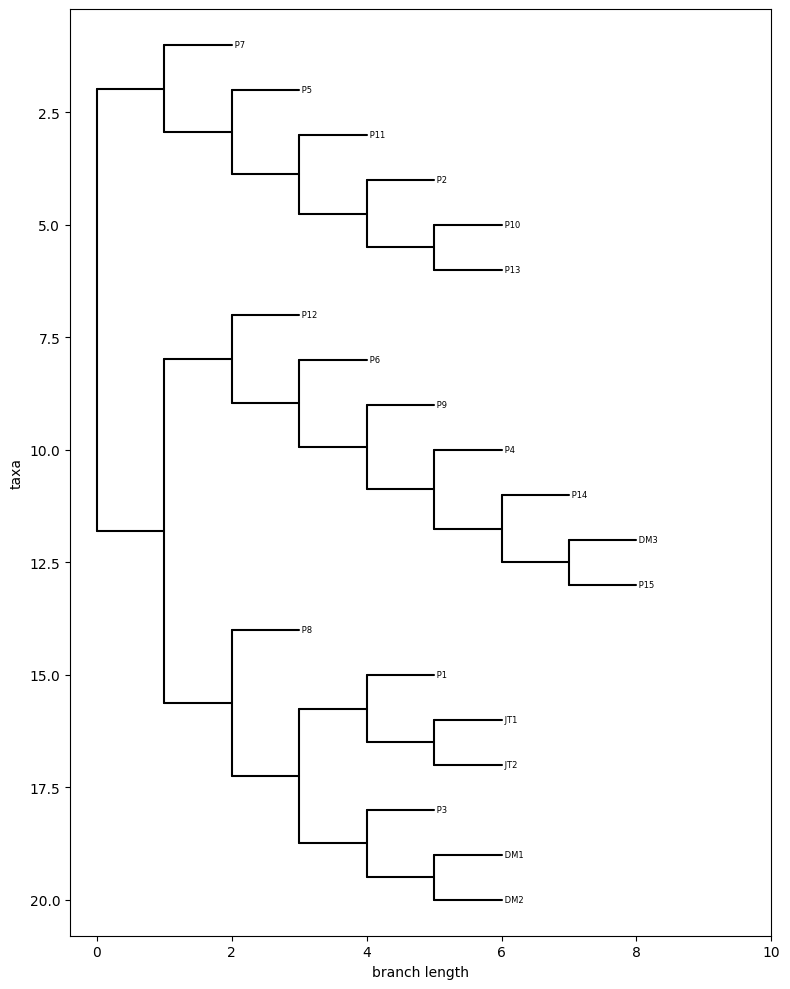

In [ ]:
if __name__ == "__main__":
    # Read HIV RT sequences
    sequences = read_fasta("lafayette_SARS_RT.fasta")
    
    # Build distance matrix using Smith-Waterman
    dist_matrix, seq_ids = build_distance_matrix(sequences)
    print(f"Distance matrix shape: {dist_matrix.shape}\n"
          f"sequence_ids:{seq_ids}")
    print(dist_matrix[0:3,0:3])
    
    # Generate unrooted tree using Neighbor-Joining
    tree = str(neighbor_joining(dist_matrix, seq_ids))
    print(tree)
    print(tree.startswith("((DM1:0.002,DM2:0.002)"))
    print(tree.count(","))
    
    # Plot tree
    plot_tree(tree)